In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
df = pd.read_csv('../data/raw/raw.csv', index_col="Date",
                 parse_dates=True)
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-06-29,67.290001,67.333336,63.234669,64.600670,135396000
2020-06-30,71.987335,72.512665,66.915337,67.099998,253777500
2020-07-01,74.641998,75.688667,72.033333,72.199997,199903500
2020-07-02,80.577332,81.866669,79.040001,81.431999,258751500
2020-07-06,91.438667,91.852669,84.402664,85.112663,308548500


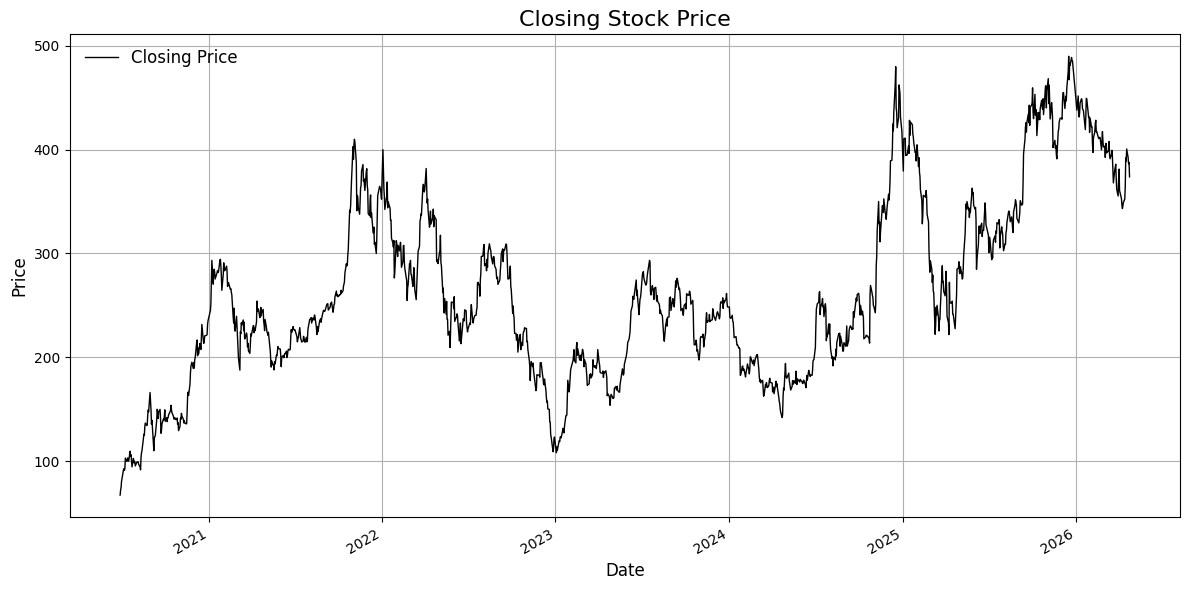

In [4]:
plt.figure(figsize=(12, 6))


df['Close'].plot(label='Closing Price', color='black', linewidth=1)

plt.title('Closing Stock Price', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.grid(True)

plt.legend(loc='best', fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

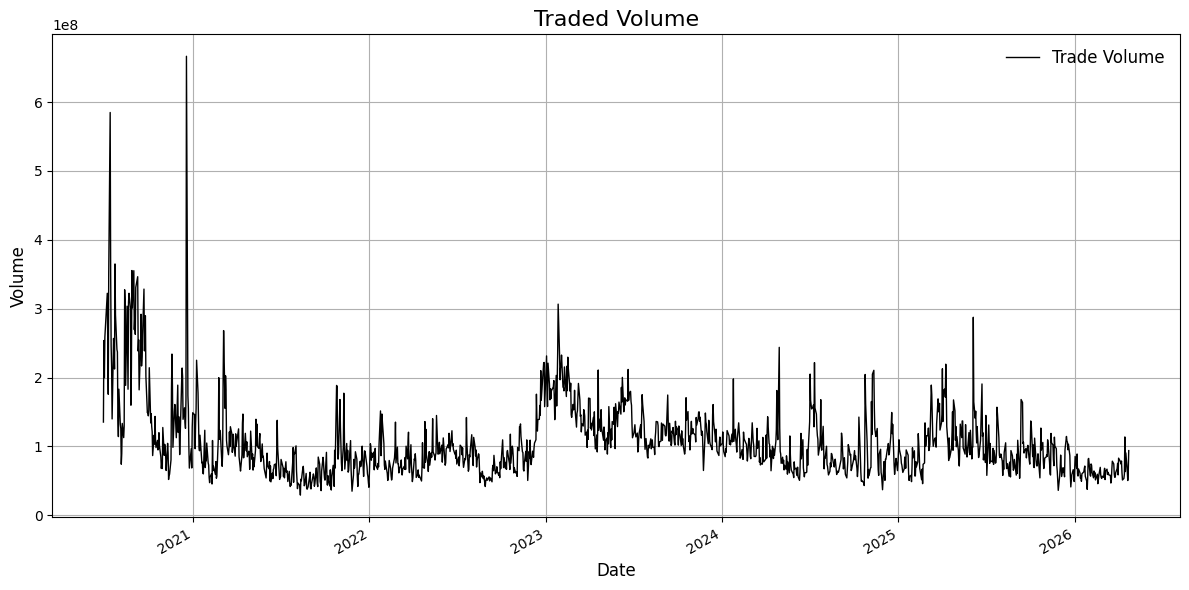

In [15]:
plt.figure(figsize=(12, 6))

df['Volume'].plot(label='Trade Volume', color='black', linewidth=1)

plt.title('Traded Volume', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volume', fontsize=12)

plt.grid(True)

plt.legend(loc='best', fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

In [6]:
new_df = df.copy()

In [7]:
new_df['day_of_week'] = new_df.index.dayofweek
new_df['month'] = new_df.index.month
new_df['quarter'] = new_df.index.quarter
new_df.head()

,Close,High,Low,Open,Volume,day_of_week,month,quarter
Date,,,,,,,,
2020-06-29,67.290001,67.333336,63.234669,64.600670,135396000,0,6,2
2020-06-30,71.987335,72.512665,66.915337,67.099998,253777500,1,6,2
2020-07-01,74.641998,75.688667,72.033333,72.199997,199903500,2,7,3
2020-07-02,80.577332,81.866669,79.040001,81.431999,258751500,3,7,3
2020-07-06,91.438667,91.852669,84.402664,85.112663,308548500,0,7,3


In [8]:
new_df['return'] = new_df['Close'].pct_change()
new_df['is_positive'] = new_df['return'] > 0

In [10]:
new_df['is_last_day_of_month'] = new_df.index.is_month_end

month_end_days = new_df[new_df['is_last_day_of_month'] == True]
regular_days   = new_df[new_df['is_last_day_of_month'] == False]

print("--- Average Returns ---")
print(f"Last Day of Month: {month_end_days['return'].mean() * 100:.3f}%")
print(f"All Other Days:    {regular_days['return'].mean() * 100:.3f}%")

print("\n--- Win Rates ---")
print(f"Last Day of Month: {month_end_days['is_positive'].mean() * 100:.2f}%")
print(f"All Other Days:    {regular_days['is_positive'].mean() * 100:.2f}%")

--- Average Returns ---
Last Day of Month: 1.052%
All Other Days:    0.163%

--- Win Rates ---
Last Day of Month: 51.02%
All Other Days:    52.30%


In [11]:
new_df['is_first_day_of_month'] = new_df.index.is_month_start

# --- FILTER 1: Quarter-End Last Days Only ---
# Quarter-end months are March (3), June (6), September (9), December (12)
quarter_end_months = [3, 6, 9, 12]
is_quarter_end = new_df['is_last_day_of_month'] & new_df['month'].isin(quarter_end_months)

q_end_days = new_df[is_quarter_end]
reg_month_end_days = new_df[new_df['is_last_day_of_month'] & ~new_df['month'].isin(quarter_end_months)]

print("=== DEEP DIVE 1: QUARTER-END VS REGULAR MONTH-END ===")
print(f"Quarter-End Last Day Avg Return: {q_end_days['return'].mean() * 100:.3f}% (Win Rate: {q_end_days['is_positive'].mean() * 100:.2f}%)")
print(f"Regular Month-End Last Day Avg Return: {reg_month_end_days['return'].mean() * 100:.3f}% (Win Rate: {reg_month_end_days['is_positive'].mean() * 100:.2f}%)")


# --- FILTER 2: First Day of the Next Month ---
first_days = new_df[new_df['is_first_day_of_month'] == True]
all_other_days = new_df[new_df['is_first_day_of_month'] == False]

print("\n=== DEEP DIVE 2: FIRST DAY OF THE MONTH TREND ===")
print(f"First Day of Month Avg Return:   {first_days['return'].mean() * 100:.3f}% (Win Rate: {first_days['is_positive'].mean() * 100:.2f}%)")
print(f"All Other Days Avg Return:       {all_other_days['return'].mean() * 100:.3f}% (Win Rate: {all_other_days['is_positive'].mean() * 100:.2f}%)")


=== DEEP DIVE 1: QUARTER-END VS REGULAR MONTH-END ===
Quarter-End Last Day Avg Return: 0.789% (Win Rate: 47.37%)
Regular Month-End Last Day Avg Return: 1.218% (Win Rate: 53.33%)

=== DEEP DIVE 2: FIRST DAY OF THE MONTH TREND ===
First Day of Month Avg Return:   0.372% (Win Rate: 44.44%)
All Other Days Avg Return:       0.187% (Win Rate: 52.51%)


/var/folders/r1/_y8cwcts1b34n2wcf8d6719m0000gn/T/ipykernel_86343/1998496642.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/r1/_y8cwcts1b34n2wcf8d6719m0000gn/T/ipykernel_86343/1998496642.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/r1/_y8cwcts1b34n2wcf8d6719m0000gn/T/ipykernel_86343/1998496642.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


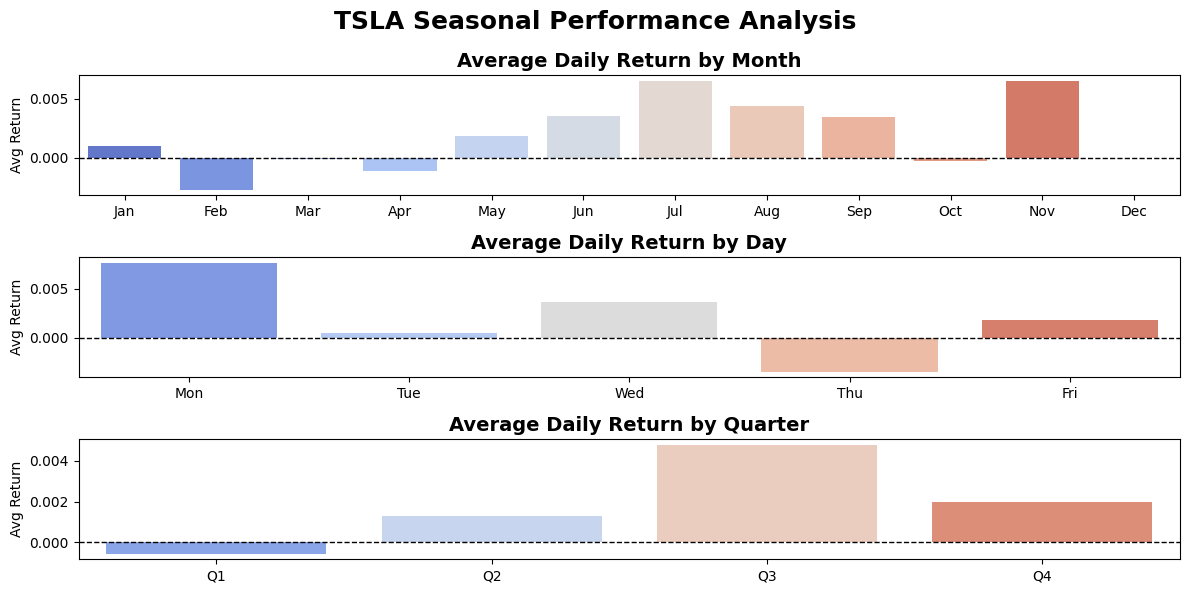

In [12]:
df_seasonal = new_df.copy()
df_seasonal['Month_Name'] = df_seasonal.index.strftime('%b') # Jan, Feb, etc.
df_seasonal['Day_Name'] = df_seasonal.index.strftime('%a')   # Mon, Tue, etc.
df_seasonal['Quarter_Name'] = 'Q' + df_seasonal.index.quarter.astype(str)

time_orders = {
    'Month_Name': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Day_Name': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
    'Quarter_Name': ['Q1', 'Q2', 'Q3', 'Q4']
}

fig, axes = plt.subplots(3, 1, figsize=(12, 6))
fig.suptitle('TSLA Seasonal Performance Analysis', fontsize=18, weight='bold', y=0.98)

for i, (col, order) in enumerate(time_orders.items()):
    sns.barplot(
        ax=axes[i],
        data=df_seasonal,
        x=col,              
        y='return',
        order=order,      
        palette='coolwarm',
        errorbar=None
    )

    # Cleans up 'Month_Name' -> 'Month' for the titles
    clean_title = col.split('_')[0]
    axes[i].set_title(f'Average Daily Return by {clean_title}', fontsize=14, weight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Avg Return')
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

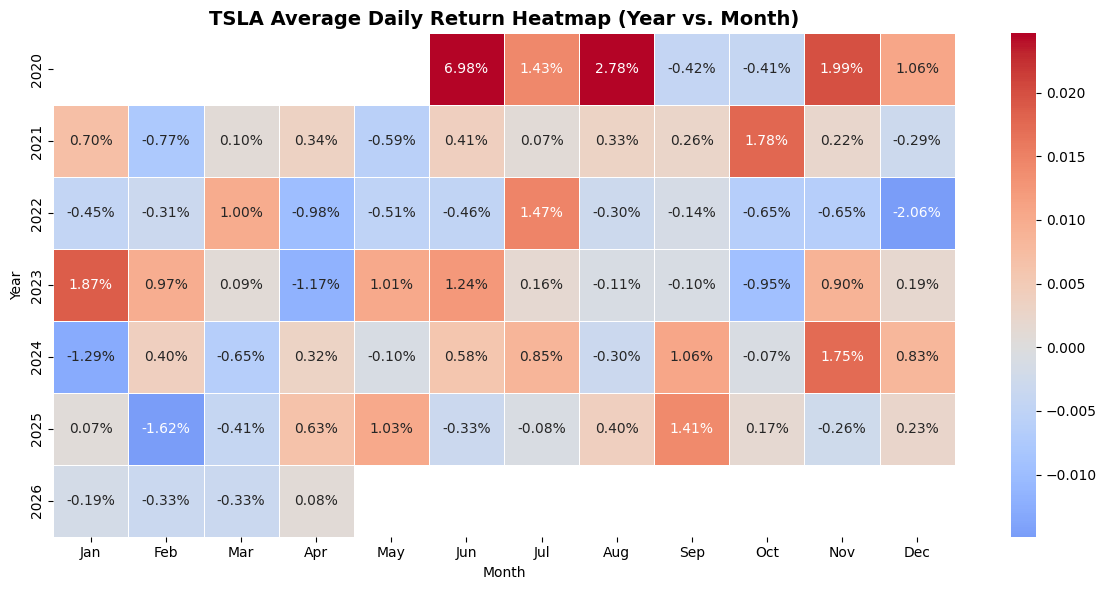

In [13]:
df_seasonal.columns = df_seasonal.columns.get_level_values(0)
df_seasonal['Year'] = df_seasonal.index.year
df_seasonal['Month_Name'] = df_seasonal.index.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

price_pivot = df_seasonal.pivot_table(
    values='return',
    index='Year',
    columns='Month_Name',
    aggfunc='mean'
)
price_pivot = price_pivot.reindex(columns=month_order)

price_pivot = price_pivot.dropna(how='all')
plt.figure(figsize=(12, 6))
sns.heatmap(
    price_pivot,
    cmap='coolwarm',
    annot=True,
    fmt=".2%",
    linewidths=0.5,
    center=0.0,
    robust=True,
    mask=price_pivot.isnull()
)

plt.title('TSLA Average Daily Return Heatmap (Year vs. Month)', fontsize=14, weight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

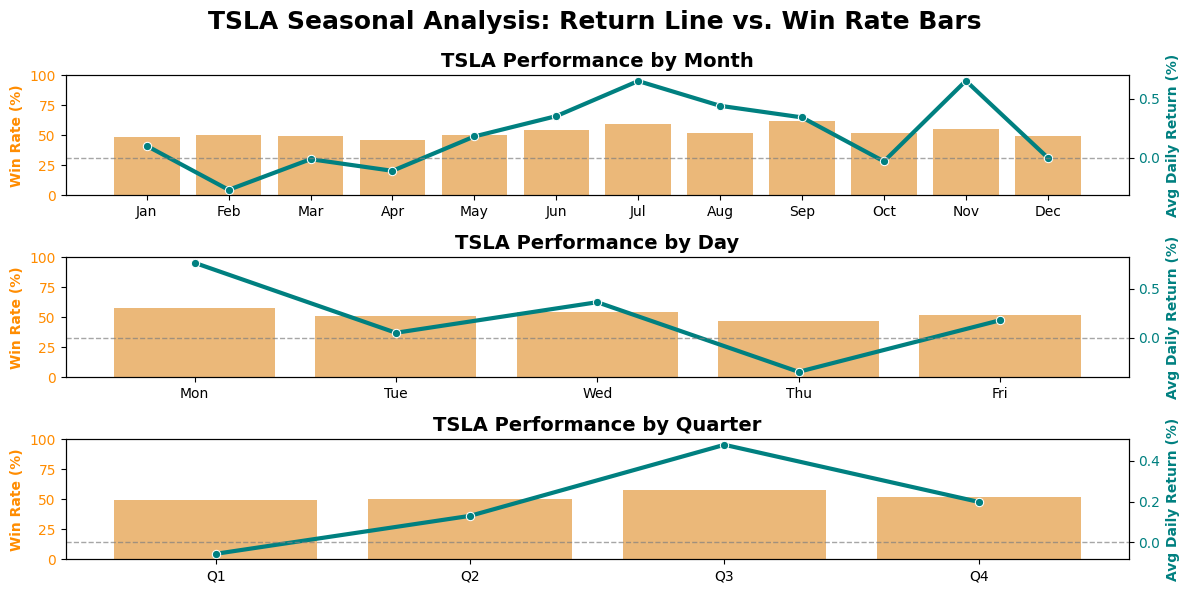

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))
fig.suptitle('TSLA Seasonal Analysis: Return Line vs. Win Rate Bars', fontsize=18, weight='bold', y=0.98)

for i, (col, order) in enumerate(time_orders.items()):
    stats = df_seasonal.groupby(col).agg(
        avg_return=('return', lambda x: x.mean() * 100),
        win_rate=('is_positive', lambda x: x.mean() * 100)
    ).reindex(order) # Ensures chronological order

    # Left Axis (ax_left): Win Rate as Bars
    ax_left = axes[i]
    sns.barplot(
        ax=ax_left,
        x=stats.index,
        y=stats['win_rate'],
        color='darkorange',
        alpha=0.6, 
        order=order
    )
    ax_left.set_ylabel('Win Rate (%)', color='darkorange', weight='bold')
    ax_left.tick_params(axis='y', labelcolor='darkorange')
    ax_left.set_ylim(0, 100) # Lock win rate securely between 0 and 100%

    # Right Axis (ax_right): Average Return as a Line Chart
    ax_right = ax_left.twinx()
    sns.lineplot(
        ax=ax_right,
        x=stats.index,
        y=stats['avg_return'],
        color='teal',
        linewidth=3,
        marker='o', # Adds solid dots on each data point
        sort=False
    )
    ax_right.set_ylabel('Avg Daily Return (%)', color='teal', weight='bold')
    ax_right.tick_params(axis='y', labelcolor='teal')

    # Visual anchors & Titles
    ax_right.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    clean_title = col.split('_')[0]
    ax_left.set_title(f'TSLA Performance by {clean_title}', fontsize=14, weight='bold')
    ax_left.set_xlabel('')

plt.tight_layout()
plt.show()